## Step 1. Project Initialization: Environment & Library Integration
The following cells prepare the workspace for the NLP pipeline:

1. **Environment Setup**: Installs core dependencies silently and downloads essential linguistic models (NLTK/spaCy).
2. **Library Integration**: Imports the necessary toolkit for data manipulation, visualization, Natural Language Processing, and machine learning modeling.

In [24]:
# Imports

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Natural Language Processing and text cleaning
import re
import nltk
import spacy
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.sentiment import SentimentIntensityAnalyzer

# Download NLTK resources
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('vader_lexicon', quiet=True)


# Machine Learning: preprocessing, modeling, and evaluation
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils import resample



## Step 2. Data Acquisition 
Load the processed dataset into the environment for initial inspection. 
* **Source**: `all_data.csv`
* **Objective**: Verify successful data ingestion and preview the first few records to understand the feature structure.

In [5]:
# Load the dataset

df = pd.read_csv('../data/all_data.csv')
df.head()

,Product Name,Price,Review
0,Acer Aspire 3 A315-24P AMD Ryzen 3 7320U 8GB R...,"Tk 53,060",I Bought this one about one year ago.\r\nIts a...
1,Lenovo IdeaPad 1 15AMN7 AMD Ryzen 3 7320U 8GB ...,"Tk 54,790",Overall good deal as per price.
2,Lenovo IdeaPad 1 15AMN7 AMD Ryzen 3 7320U 8GB ...,"Tk 54,790",Hope the quality of this product will be very ...
3,Lenovo IdeaPad 1 15AMN7 AMD Ryzen 3 7320U 8GB ...,"Tk 54,790",Great affordable performance
4,Lenovo IdeaPad 1 15AMN7 AMD Ryzen 3 7320U 8GB ...,"Tk 54,790",Good product


## Step 3. Text Pre-processing & Sentiment Labeling
This stage prepares the text for modeling and analyzes the resulting class distribution:
1.  **Text Cleaning**: Normalizes reviews by removing URLs, noise, and stopwords while applying lemmatization.
2.  **Sentiment Analysis**: Categorizes reviews using VADER polarity scores.
3.  **Distribution Visualization**: A count plot is generated to inspect for class imbalance, which informs our modeling strategy.

In [ ]:
# Initialize NLP tools
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Define a function to clean the text data
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = nltk.word_tokenize(text)
    return " ".join([lemmatizer.lemmatize(w) for w in tokens if w not in stop_words and len(w) > 2])
    
    # Define Sentiment Labeling Function
def get_sentiment(text):
    score = sia.polarity_scores(str(text))['compound']
    if score >= 0.05: return 'positive'
    if score <= -0.05: return 'negative'
    return 'neutral'

# 4. Apply transformations to the dataset
df['clean_text'] = df['Review'].apply(clean_text)
df['sentiment'] = df['Review'].apply(get_sentiment)

# Preview results and distribution
print(df['sentiment'].value_counts())
df[['Review', 'clean_text', 'sentiment']].head()


sentiment
positive    20838
neutral      4729
negative      324
Name: count, dtype: int64


,Review,clean_text,sentiment
0,I Bought this one about one year ago.\r\nIts a...,bought one one year ago good laptop basic work...,positive
1,Overall good deal as per price.,overall good deal per price,positive
2,Hope the quality of this product will be very ...,hope quality product good,positive
3,Great affordable performance,great affordable performance,positive
4,Good product,good product,positive


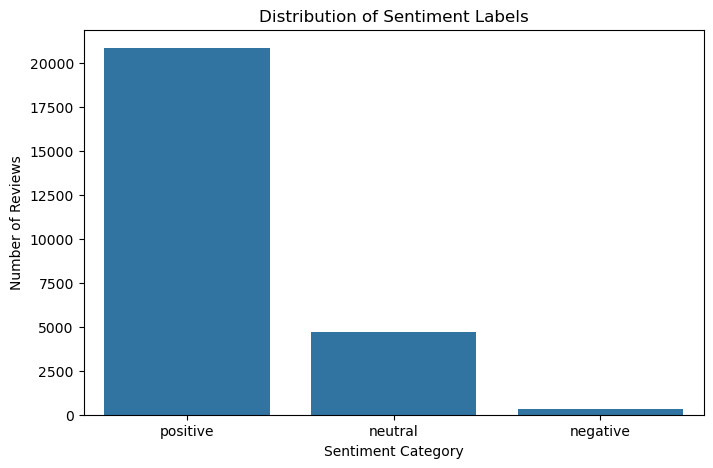

In [30]:
 # Visualize Sentiment Distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='sentiment', data=df)
plt.title('Distribution of Sentiment Labels')
plt.xlabel('Sentiment Category')
plt.ylabel('Number of Reviews')
plt.show()


In [13]:
# Train-test split

X = df['clean_text']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [14]:
nb_pipeline = Pipeline([
    ('vectorizer', CountVectorizer()),
    ('nb', MultinomialNB())
])

nb_pipeline.fit(X_train, y_train)

y_pred = nb_pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8824097316084186
              precision    recall  f1-score   support

    negative       0.58      0.17      0.26        65
     neutral       0.92      0.45      0.61       946
    positive       0.88      0.99      0.93      4168

    accuracy                           0.88      5179
   macro avg       0.79      0.54      0.60      5179
weighted avg       0.88      0.88      0.86      5179



In [18]:
# Combine for resampling
train_df = pd.DataFrame({'text': X_train, 'label': y_train})

# Separate classes
df_pos = train_df[train_df.label == 'positive']
df_neu = train_df[train_df.label == 'neutral']
df_neg = train_df[train_df.label == 'negative']

# Upsample minority classes
df_neu_up = resample(df_neu, 
                     replace=True, 
                     n_samples=len(df_pos), 
                     random_state=42)

df_neg_up = resample(df_neg, 
                     replace=True, 
                     n_samples=len(df_pos), 
                     random_state=42)

# Combine back
train_balanced = pd.concat([df_pos, df_neu_up, df_neg_up])

X_train_bal = train_balanced['text']
y_train_bal = train_balanced['label']

y_train_bal.value_counts()

label
positive    16670
neutral     16670
negative    16670
Name: count, dtype: int64

In [19]:
nb_balanced = Pipeline([
    ('vectorizer', TfidfVectorizer()),
    ('nb', MultinomialNB())
])

nb_balanced.fit(X_train_bal, y_train_bal)

y_pred_bal = nb_balanced.predict(X_test)

print("Balanced NB Accuracy:", accuracy_score(y_test, y_pred_bal))
print(classification_report(y_test, y_pred_bal))

Balanced NB Accuracy: 0.8795134195790694
              precision    recall  f1-score   support

    negative       0.08      0.58      0.13        65
     neutral       0.92      0.55      0.69       946
    positive       0.97      0.96      0.96      4168

    accuracy                           0.88      5179
   macro avg       0.66      0.70      0.60      5179
weighted avg       0.95      0.88      0.90      5179



In [20]:
tfidf = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1,2),
    min_df=5,
    max_df=0.7
)

nb_tuned = Pipeline([
    ('vectorizer', tfidf),
    ('nb', MultinomialNB())
])

nb_tuned.fit(X_train, y_train)
y_pred = nb_tuned.predict(X_test)

print("Tuned NB Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Tuned NB Accuracy: 0.8802857694535625
              precision    recall  f1-score   support

    negative       0.38      0.05      0.08        65
     neutral       0.90      0.46      0.61       946
    positive       0.88      0.99      0.93      4168

    accuracy                           0.88      5179
   macro avg       0.72      0.50      0.54      5179
weighted avg       0.88      0.88      0.86      5179



In [21]:
nb_tuned = Pipeline([
    ('vectorizer', tfidf),
    ('nb', MultinomialNB(class_prior=[1/3, 1/3, 1/3]))
])